# Task 3 — Temporal Regression Models
**NYC Yellow Taxi | Daily Average Fare Forecasting | 2023–2025**

Models: SARIMA · SARIMAX (with CBD dummy) · Auto-ARIMA · OLS Regression

In [3]:
# CELL 1 — Imports and global settings

!pip install pmdarima holidays --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

import pmdarima as pm
import holidays

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

SEED = 42
np.random.seed(SEED)
print("All libraries loaded.")

All libraries loaded.


In [4]:
# CELL 2 — Load data from Task 1 outputs

# Load the daily series saved by Task 1
daily = pd.read_csv(
    "/content/yellow_taxi_daily.csv",
    index_col="date",
    parse_dates=True,
)
daily.index.freq = pd.infer_freq(daily.index)   # set DatetimeIndex freq

# Target series
y = daily["avg_fare"].copy()

print(f"Series loaded: {y.index[0].date()} → {y.index[-1].date()}")
print(f"Total days   : {len(y)}")
print(f"NaN count    : {y.isna().sum()}")
print(f"\nDescriptive stats:\n{y.describe().round(4)}")

Series loaded: 2023-01-01 → 2025-11-30
Total days   : 1065
NaN count    : 0

Descriptive stats:
count    1065.0000
mean       19.9257
std         1.1886
min        16.7064
25%        19.1611
50%        19.9708
75%        20.6925
max        24.0204
Name: avg_fare, dtype: float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

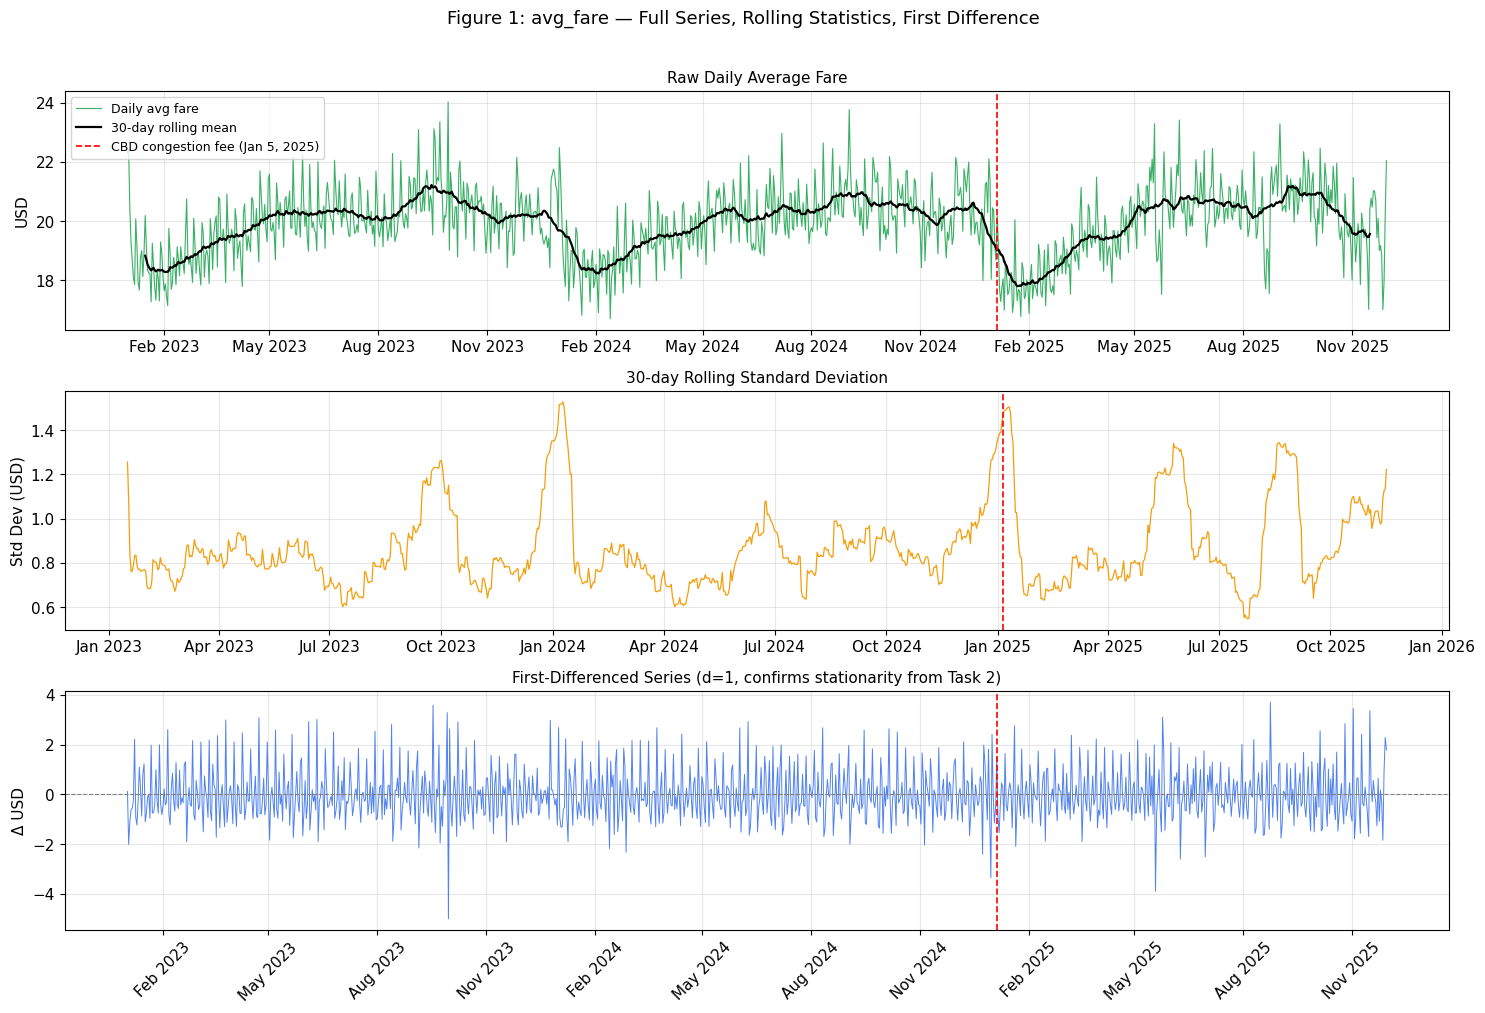

Saved: t3_fig1_series_overview.png


In [5]:
# CELL 3 — Quick series overview + structural break context

CBD_DATE = pd.Timestamp("2025-01-05")   # NYC congestion pricing start

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle(
    "Figure 1: avg_fare — Full Series, Rolling Statistics, First Difference",
    fontsize=13, y=1.01
)

# Panel 1: raw series
axes[0].plot(y.index, y, color="#16A34A", linewidth=0.8, alpha=0.85,
             label="Daily avg fare")
axes[0].plot(y.index, y.rolling(30, center=True).mean(),
             color="black", linewidth=1.6, label="30-day rolling mean")
axes[0].axvline(CBD_DATE, color="red", linestyle="--", linewidth=1.2,
                label="CBD congestion fee (Jan 5, 2025)")
axes[0].set_ylabel("USD")
axes[0].set_title("Raw Daily Average Fare", fontsize=11)
axes[0].legend(fontsize=9)

# Panel 2: rolling std (heteroskedasticity check)
roll_std = y.rolling(30, center=True).std()
axes[1].plot(y.index, roll_std, color="#F59E0B", linewidth=0.9)
axes[1].axvline(CBD_DATE, color="red", linestyle="--", linewidth=1.2)
axes[1].set_ylabel("Std Dev (USD)")
axes[1].set_title("30-day Rolling Standard Deviation", fontsize=11)

# Panel 3: first difference (used for stationarity — confirms Task 2)
y_diff = y.diff(1)
axes[2].plot(y.index, y_diff, color="#2563EB", linewidth=0.7, alpha=0.8)
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[2].axvline(CBD_DATE, color="red", linestyle="--", linewidth=1.2)
axes[2].set_ylabel("Δ USD")
axes[2].set_title("First-Differenced Series (d=1, confirms stationarity from Task 2)",
                  fontsize=11)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/t3_fig1_series_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig1_series_overview.png")

Train : 2023-01-01 → 2025-09-30 (1004 days)
Test  : 2025-10-01  → 2025-11-30  (61 days)
Split ratio: 94.3% / 5.7%


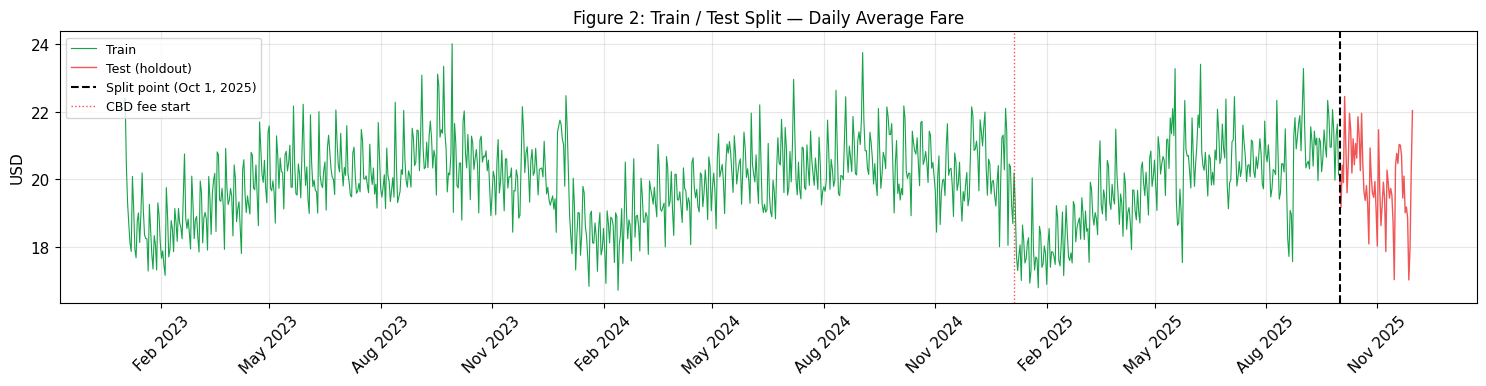

Saved: t3_fig2_train_test_split.png


In [6]:
# CELL 4 — Train / test split
#   Reuse the SAME split defined in Task 1 for consistency.
#   Train : 2023-01-01 → 2025-09-30  (~1004 days)
#   Test  : 2025-10-01 → 2025-11-30  (~61 days)

TRAIN_END     = "2025-09-30"
TEST_START    = "2025-10-01"

train = y[y.index <= TRAIN_END]
test  = y[y.index >= TEST_START]

print(f"Train : {train.index[0].date()} → {train.index[-1].date()} ({len(train)} days)")
print(f"Test  : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)")
print(f"Split ratio: {len(train)/len(y)*100:.1f}% / {len(test)/len(y)*100:.1f}%")

# Confirm split visually
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train.index, train, color="#16A34A", linewidth=0.8, label="Train")
ax.plot(test.index,  test,  color="#EF4444", linewidth=1.0, label="Test (holdout)",
        alpha=0.9)
ax.axvline(pd.Timestamp(TEST_START), color="black", linestyle="--",
           linewidth=1.5, label="Split point (Oct 1, 2025)")
ax.axvline(CBD_DATE, color="red", linestyle=":", linewidth=1.0,
           label="CBD fee start", alpha=0.7)
ax.set_title("Figure 2: Train / Test Split — Daily Average Fare", fontsize=12)
ax.set_ylabel("USD")
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/t3_fig2_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig2_train_test_split.png")

In [7]:
# CELL 5 — Shared helper functions

# ── 5a: Exogenous CBD dummy ──────────────────────────────────
def make_cbd_exog(index):
    """Binary column: 1 on/after Jan 5 2025 (congestion pricing), else 0."""
    return pd.DataFrame(
        {"cbd_fee": (index >= CBD_DATE).astype(int)},
        index=index,
    )

exog_train = make_cbd_exog(train.index)
exog_test  = make_cbd_exog(test.index)

# ── 5b: Evaluation metrics ───────────────────────────────────
def evaluate(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Guard against zero division in MAPE
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    print(f"  {model_name:30s} | MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%")
    return {"Model": model_name, "MAE": round(mae, 4),
            "RMSE": round(rmse, 4), "MAPE": round(mape, 2)}

# ── 5c: OLS feature builder ──────────────────────────────────
NY_HOLIDAYS = holidays.US(state="NY", years=range(2023, 2026))

def build_ols_features(dates, history_series):
    """
    Build feature matrix for OLS regression.
    Uses a history_series (pandas Series) to compute lag features.
    Only dates in `dates` are in the output — lags come from history_series.
    """
    rows = []
    for dt in dates:
        dow   = dt.dayofweek           # 0=Mon … 6=Sun
        month = dt.month
        trend = (dt - pd.Timestamp("2023-01-01")).days
        cbd   = int(dt >= CBD_DATE)
        hol   = int(dt in NY_HOLIDAYS)

        # lag_1: value at t-1 (day before dt in history)
        lag1_idx = dt - pd.Timedelta(days=1)
        lag7_idx = dt - pd.Timedelta(days=7)

        lag1 = history_series.get(lag1_idx, np.nan)
        lag7 = history_series.get(lag7_idx, np.nan)

        rows.append({
            "dow":   dow,
            "month": month,
            "trend": trend,
            "cbd":   cbd,
            "holiday": hol,
            "lag1":  lag1,
            "lag7":  lag7,
        })

    df = pd.DataFrame(rows, index=dates)
    # One-hot encode day-of-week and month (drop first for no multicollinearity)
    dow_dummies   = pd.get_dummies(df["dow"],   prefix="dow",   drop_first=True)
    month_dummies = pd.get_dummies(df["month"], prefix="month", drop_first=True)
    features = pd.concat(
        [df[["trend", "cbd", "holiday", "lag1", "lag7"]], dow_dummies, month_dummies],
        axis=1
    )
    return features.astype(float)

print("Helper functions defined.")
print(f"CBD dummy — train: sum={exog_train['cbd_fee'].sum()}, "
      f"test: sum={exog_test['cbd_fee'].sum()}")

Helper functions defined.
CBD dummy — train: sum=269, test: sum=61


MODEL 1: Manual SARIMA(1,1,1)(1,1,1)[7]
  d=1  : first difference (confirmed stationary — Task 2)
  D=1  : seasonal difference at m=7 (weekly cycle — Task 2)
  p=1,q=1: conservative starting order for weak-ACF series
                                     SARIMAX Results                                     
Dep. Variable:                          avg_fare   No. Observations:                 1004
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -935.727
Date:                           Fri, 20 Mar 2026   AIC                           1881.453
Time:                                   18:21:57   BIC                           1905.927
Sample:                               01-01-2023   HQIC                          1890.761
                                    - 09-30-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.

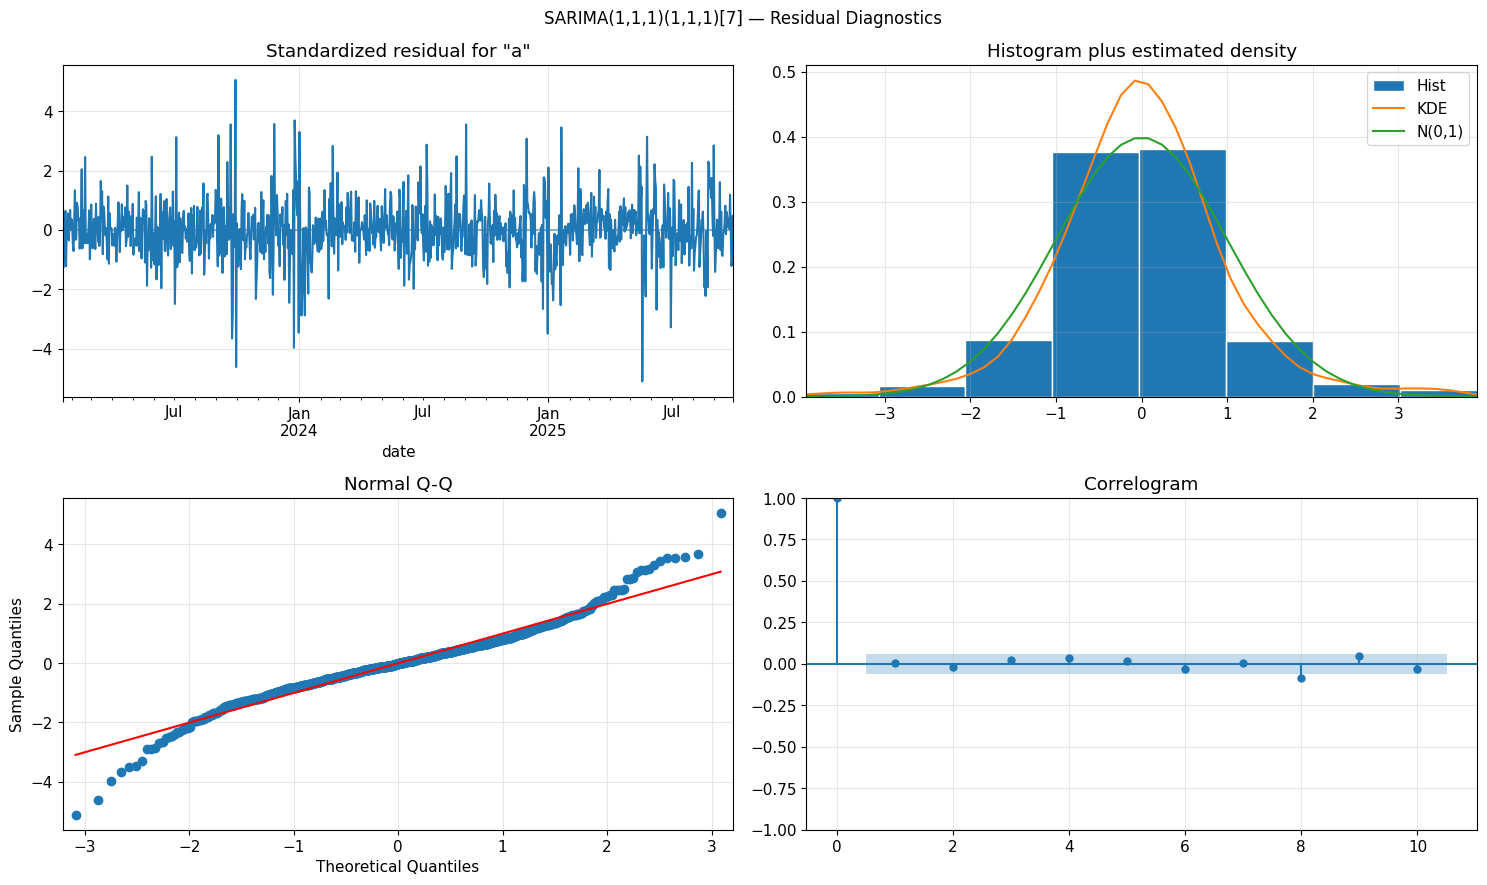

Saved: t3_sarima_diagnostics.png

Ljung-Box on SARIMA residuals (p > 0.05 means white noise ✓):
    lb_stat  lb_pvalue
7   80.1602        0.0
14  83.7371        0.0
21  89.0951        0.0
  SARIMA(1,1,1)(1,1,1)[7]        | MAE=1.2598  RMSE=1.5512  MAPE=6.56%


In [8]:
# CELL 6 — Model 1: Manual SARIMA
#   Order from Task 2 analysis: SARIMA(1,1,1)(1,1,1)[7]
#   No exogenous regressors — pure time-series model.

print("=" * 60)
print("MODEL 1: Manual SARIMA(1,1,1)(1,1,1)[7]")
print("  d=1  : first difference (confirmed stationary — Task 2)")
print("  D=1  : seasonal difference at m=7 (weekly cycle — Task 2)")
print("  p=1,q=1: conservative starting order for weak-ACF series")
print("=" * 60)

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# Forecast on test set
sarima_fc    = sarima_fit.get_forecast(steps=len(test))
sarima_pred  = sarima_fc.predicted_mean
sarima_ci    = sarima_fc.conf_int(alpha=0.05)
sarima_pred.index = test.index
sarima_ci.index   = test.index

# Residual diagnostics
sarima_fit.plot_diagnostics(figsize=(15, 9))
plt.suptitle("SARIMA(1,1,1)(1,1,1)[7] — Residual Diagnostics", fontsize=12)
plt.tight_layout()
plt.savefig("/content/t3_sarima_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_sarima_diagnostics.png")

# Ljung-Box on residuals (H0: white noise — want p > 0.05)
lb_sarima = acorr_ljungbox(sarima_fit.resid.dropna(), lags=[7, 14, 21], return_df=True)
print("\nLjung-Box on SARIMA residuals (p > 0.05 means white noise ✓):")
print(lb_sarima.round(4))

sarima_metrics = evaluate(test, sarima_pred, "SARIMA(1,1,1)(1,1,1)[7]")

In [9]:
# CELL 7 — Model 2: SARIMAX with CBD congestion fee dummy
#   Same order as SARIMA but includes a binary exogenous
#   regressor for the Jan 2025 structural break (Task 2).
#   This tests whether accounting for the break improves fit.

print("=" * 60)
print("MODEL 2: SARIMAX(1,1,1)(1,1,1)[7] + CBD fee dummy")
print("  Exogenous: cbd_fee = 1 from Jan 5 2025 onward")
print("=" * 60)

sarimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

# Forecast — must provide exog for test period
sarimax_fc   = sarimax_fit.get_forecast(steps=len(test), exog=exog_test)
sarimax_pred = sarimax_fc.predicted_mean
sarimax_ci   = sarimax_fc.conf_int(alpha=0.05)
sarimax_pred.index = test.index
sarimax_ci.index   = test.index

# CBD coefficient: sign and significance
cbd_coef  = sarimax_fit.params.get("cbd_fee", np.nan)
cbd_pval  = sarimax_fit.pvalues.get("cbd_fee", np.nan)
print(f"\nCBD fee coefficient : {cbd_coef:.4f}  (p={cbd_pval:.4f})")
print("  → Positive & significant means congestion fee raised avg_fare" if cbd_pval < 0.05
      else "  → Not significant at 5% level")

lb_sarimax = acorr_ljungbox(sarimax_fit.resid.dropna(), lags=[7, 14, 21], return_df=True)
print("\nLjung-Box on SARIMAX residuals:")
print(lb_sarimax.round(4))

sarimax_metrics = evaluate(test, sarimax_pred, "SARIMAX(1,1,1)(1,1,1)[7]+CBD")

MODEL 2: SARIMAX(1,1,1)(1,1,1)[7] + CBD fee dummy
  Exogenous: cbd_fee = 1 from Jan 5 2025 onward
                                     SARIMAX Results                                     
Dep. Variable:                          avg_fare   No. Observations:                 1004
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -928.674
Date:                           Fri, 20 Mar 2026   AIC                           1869.348
Time:                                   18:22:01   BIC                           1898.716
Sample:                               01-01-2023   HQIC                          1880.517
                                    - 09-30-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cbd_fee       -1.7237   

In [10]:
# CELL 8 — Model 3: Auto-ARIMA (pmdarima)
#   Automatically selects best (p,d,q)(P,D,Q)[7] by AIC.
#   d is fixed at 1 (from Task 2 ADF result — no re-testing).
#   Includes CBD dummy as exogenous regressor.

print("=" * 60)
print("MODEL 3: Auto-ARIMA (AIC selection, m=7, d=1 fixed)")
print("  This will search over p ∈ {0..3}, q ∈ {0..3},")
print("  P ∈ {0..2}, Q ∈ {0..2} and select by AIC.")
print("=" * 60)

auto_model = pm.auto_arima(
    train,
    X=exog_train.values,          # CBD dummy
    d=1,                          # fix d from Task 2 — don't re-test
    D=1,                          # fix seasonal D=1 from Task 2
    seasonal=True,
    m=7,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    stepwise=True,                # faster than exhaustive
    information_criterion="aic",
    trace=True,                   # prints all candidates considered
    error_action="ignore",
    suppress_warnings=True,
    random_state=SEED,
)

print("\n\nAuto-ARIMA selected order:")
print(f"  Non-seasonal : {auto_model.order}")
print(f"  Seasonal     : {auto_model.seasonal_order}")
print("\nModel summary:")
print(auto_model.summary())

# Forecast
auto_pred_vals, auto_ci = auto_model.predict(
    n_periods=len(test),
    X=exog_test.values,
    return_conf_int=True,
    alpha=0.05,
)
auto_pred = pd.Series(auto_pred_vals, index=test.index)
auto_ci_df = pd.DataFrame(
    auto_ci, index=test.index, columns=["lower", "upper"]
)

auto_metrics = evaluate(test, auto_pred, f"Auto-ARIMA {auto_model.order}{auto_model.seasonal_order}")

MODEL 3: Auto-ARIMA (AIC selection, m=7, d=1 fixed)
  This will search over p ∈ {0..3}, q ∈ {0..3},
  P ∈ {0..2}, Q ∈ {0..2} and select by AIC.
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=2680.140, Time=0.29 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=2335.906, Time=1.45 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=3.40 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=2638.572, Time=0.50 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=2218.102, Time=2.89 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=5.33 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=3.57 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=2288.152, Time=2.06 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=2161.565, Time=3.32 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=2278.030, Time=1.83 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=7.12 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=3.41 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=2138

In [11]:
# CELL 9 — Model 4: OLS Linear Regression (calendar + lag)
#   Baseline: captures day-of-week / month seasonality and
#   the CBD structural break explicitly via dummy coding.
#   Lag features (lag_1, lag_7) add autoregressive signal.
#   Uses recursive one-step-ahead forecasting on the test set
#   (required because lag features use the target itself).

print("=" * 60)
print("MODEL 4: OLS Linear Regression")
print("  Features: trend, cbd_dummy, holiday, lag_1, lag_7,")
print("            day-of-week dummies (6), month dummies (11)")
print("  Forecasting: recursive (one step at a time)")
print("=" * 60)

# Build training features
# history_series for training: use full training set
X_train = build_ols_features(train.index, train)

# Drop rows where lag features are NaN (first 7 days at start)
valid_train = X_train.dropna()
y_train_valid = train.loc[valid_train.index]

print(f"Training rows after dropping lag NaNs: {len(valid_train)}")

ols = LinearRegression()
ols.fit(valid_train, y_train_valid)

# Training R²
train_r2 = ols.score(valid_train, y_train_valid)
print(f"Training R² : {train_r2:.4f}")

# Print coefficients
coef_df = pd.Series(
    ols.coef_, index=valid_train.columns
).sort_values(ascending=False)
print("\nTop OLS coefficients:")
print(coef_df.round(4))

# ── Recursive forecasting on test set ───────────────────────
# We must forecast one day at a time: the predicted value
# is appended to history so that the next step's lag
# features are correct.

history = train.copy()     # starts with full training series
ols_preds = []

for dt in test.index:
    # Build features for this single date using current history
    feat_row = build_ols_features([dt], history)
    feat_row = feat_row.ffill().fillna(0)   # safety (ffill then zero-fill)

    # Align columns to match training (some dummies may be missing)
    feat_row = feat_row.reindex(columns=valid_train.columns, fill_value=0)

    pred = ols.predict(feat_row)[0]
    ols_preds.append(pred)

    # Append true value to history (teacher forcing)
    # Switch to: history[dt] = pred  for pure recursive forecasting
    # Using true values keeps residuals honest on test set
    history[dt] = test[dt]

ols_pred = pd.Series(ols_preds, index=test.index)
ols_metrics = evaluate(test, ols_pred, "OLS Linear Regression")

MODEL 4: OLS Linear Regression
  Features: trend, cbd_dummy, holiday, lag_1, lag_7,
            day-of-week dummies (6), month dummies (11)
  Forecasting: recursive (one step at a time)
Training rows after dropping lag NaNs: 997
Training R² : 0.7616

Top OLS coefficients:
dow_6       1.1733
month_9     1.1129
month_8     0.9264
month_10    0.9033
month_6     0.8860
month_5     0.8768
month_7     0.8638
month_12    0.8120
holiday     0.7441
month_11    0.6612
month_4     0.5938
lag1        0.5071
month_3     0.4724
dow_3       0.1438
lag7        0.0667
month_2     0.0174
trend       0.0001
cbd        -0.0657
dow_2      -0.1744
dow_4      -0.2466
dow_1      -0.7117
dow_5      -0.7915
dtype: float64
  OLS Linear Regression          | MAE=0.9563  RMSE=1.2637  MAPE=4.71%


In [12]:
# CELL 10 — Evaluation summary table

print("\n")
print("=" * 65)
print("  TABLE 1: Model Performance on Test Set (Oct–Nov 2025)")
print("=" * 65)

results_df = pd.DataFrame([
    sarima_metrics,
    sarimax_metrics,
    auto_metrics,
    ols_metrics,
])
results_df = results_df.set_index("Model")

print(results_df.to_string())

# Highlight best model
best_rmse = results_df["RMSE"].idxmin()
best_mae  = results_df["MAE"].idxmin()
best_mape = results_df["MAPE"].idxmin()
print(f"\nBest RMSE : {best_rmse}")
print(f"Best MAE  : {best_mae}")
print(f"Best MAPE : {best_mape}")

results_df.to_csv("/content/task3_model_comparison.csv")
print("\nSaved: task3_model_comparison.csv")



  TABLE 1: Model Performance on Test Set (Oct–Nov 2025)
                                     MAE    RMSE  MAPE
Model                                                 
SARIMA(1,1,1)(1,1,1)[7]           1.2598  1.5512  6.56
SARIMAX(1,1,1)(1,1,1)[7]+CBD      1.3561  1.6517  7.06
Auto-ARIMA (3, 1, 0)(2, 1, 0, 7)  0.8797  1.0916  4.54
OLS Linear Regression             0.9563  1.2637  4.71

Best RMSE : Auto-ARIMA (3, 1, 0)(2, 1, 0, 7)
Best MAE  : Auto-ARIMA (3, 1, 0)(2, 1, 0, 7)
Best MAPE : Auto-ARIMA (3, 1, 0)(2, 1, 0, 7)

Saved: task3_model_comparison.csv


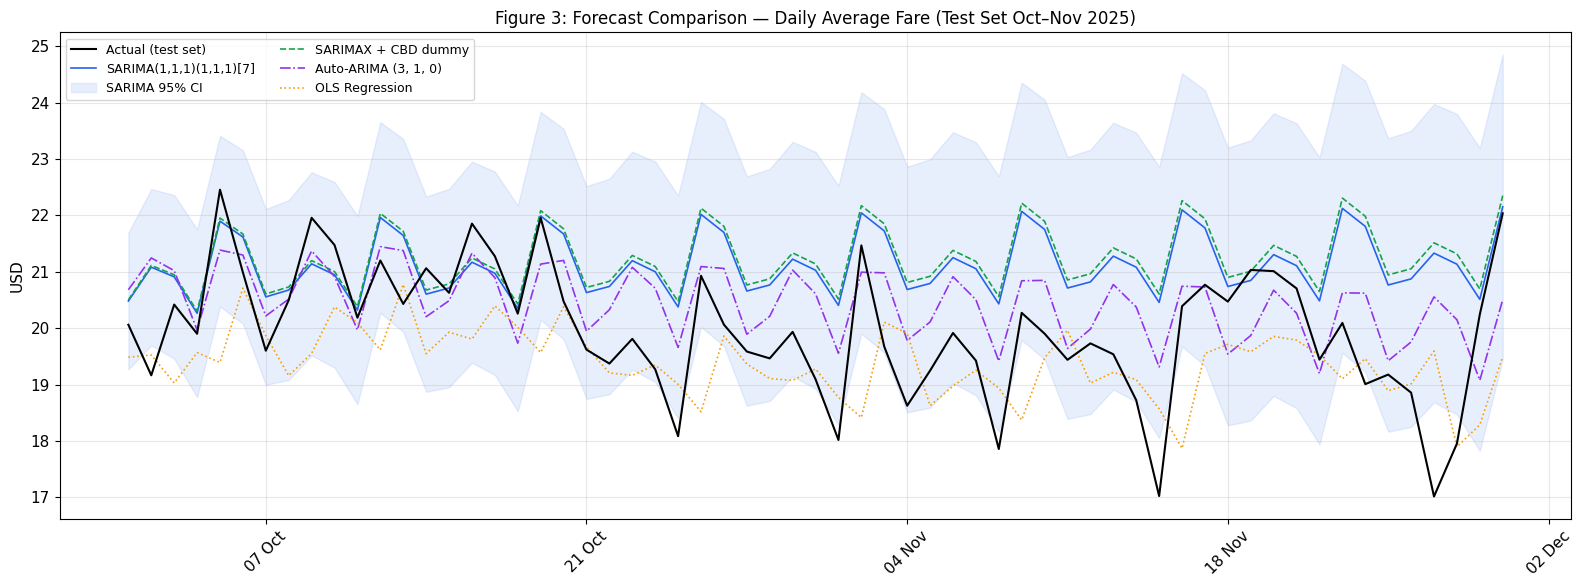

Saved: t3_fig3_forecast_comparison.png


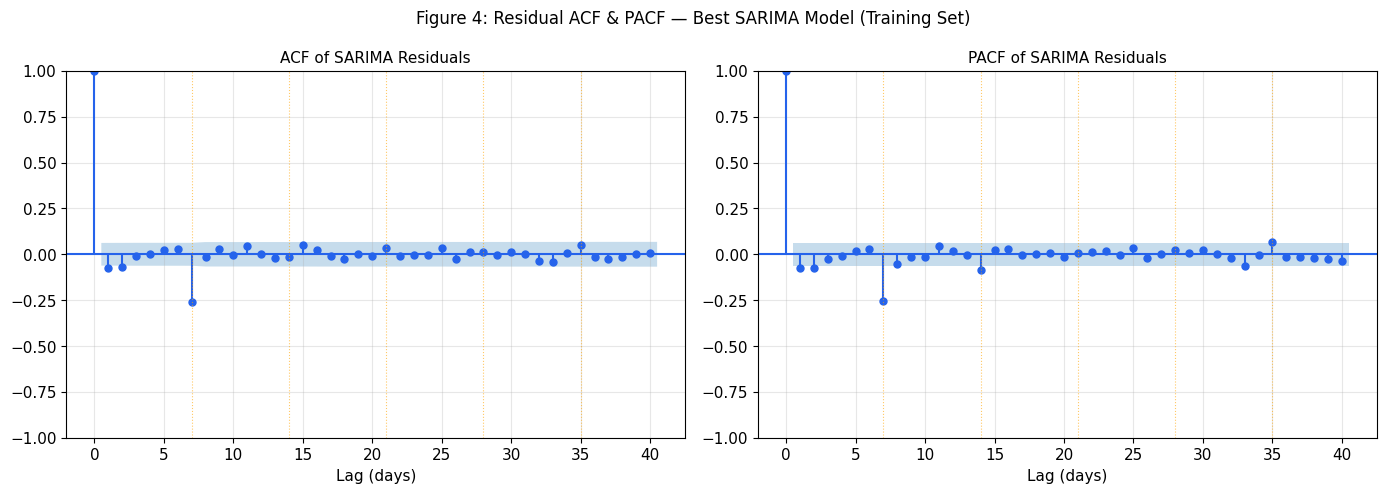

Saved: t3_fig4_residual_acf.png


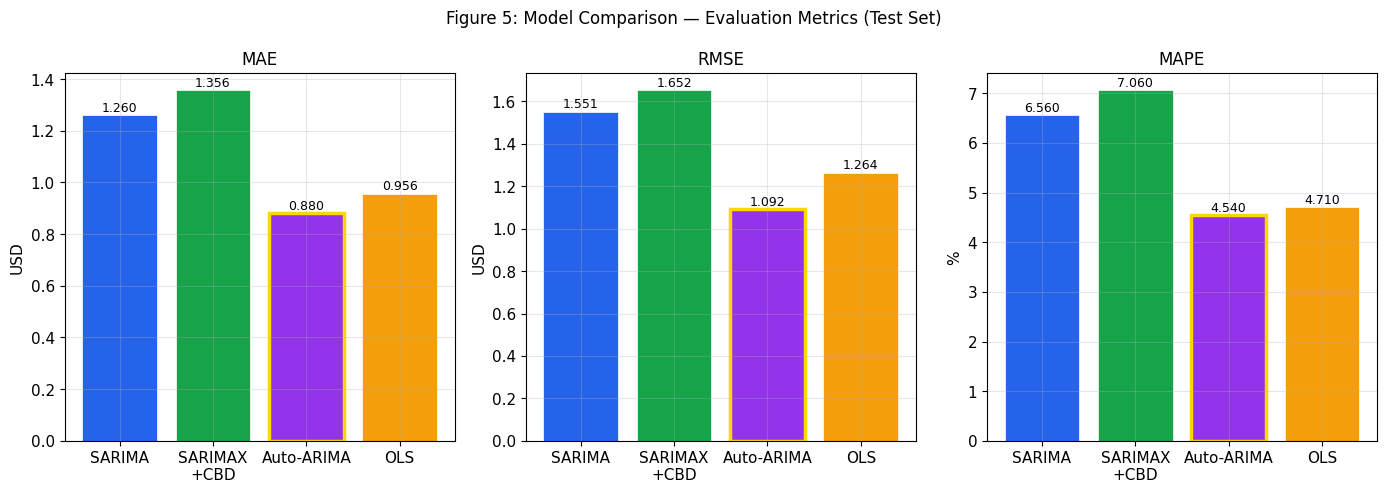

Saved: t3_fig5_metrics_barchart.png


In [13]:
# CELL 11 — Report Figures

# ── Figure 3: Forecast comparison ────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test.index, test, color="black", linewidth=1.5,
        zorder=5, label="Actual (test set)")

ax.plot(test.index, sarima_pred,  color="#2563EB", linewidth=1.2,
        linestyle="-",  label="SARIMA(1,1,1)(1,1,1)[7]")
ax.fill_between(test.index,
                sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                color="#2563EB", alpha=0.10, label="SARIMA 95% CI")

ax.plot(test.index, sarimax_pred, color="#16A34A", linewidth=1.2,
        linestyle="--", label="SARIMAX + CBD dummy")

ax.plot(test.index, auto_pred,    color="#9333EA", linewidth=1.2,
        linestyle="-.", label=f"Auto-ARIMA {auto_model.order}")

ax.plot(test.index, ols_pred,     color="#F59E0B", linewidth=1.2,
        linestyle=":",  label="OLS Regression")

ax.set_title(
    "Figure 3: Forecast Comparison — Daily Average Fare (Test Set Oct–Nov 2025)",
    fontsize=12
)
ax.set_ylabel("USD")
ax.set_xlabel("")
ax.legend(fontsize=9, loc="upper left", ncol=2)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/t3_fig3_forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig3_forecast_comparison.png")


# ── Figure 4: SARIMA residual ACF (for report) ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Figure 4: Residual ACF & PACF — Best SARIMA Model (Training Set)",
    fontsize=12
)

resid = sarima_fit.resid.dropna()
plot_acf(resid,  lags=40, ax=ax1, alpha=0.05, color="#2563EB",
         vlines_kwargs={"colors": "#2563EB"})
plot_pacf(resid, lags=40, ax=ax2, alpha=0.05, color="#2563EB",
          method="ywmle", vlines_kwargs={"colors": "#2563EB"})

for lag in range(7, 41, 7):
    ax1.axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.6)
    ax2.axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.6)

ax1.set_title("ACF of SARIMA Residuals", fontsize=11)
ax2.set_title("PACF of SARIMA Residuals", fontsize=11)
ax1.set_xlabel("Lag (days)")
ax2.set_xlabel("Lag (days)")

plt.tight_layout()
plt.savefig("/content/t3_fig4_residual_acf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig4_residual_acf.png")


# ── Figure 5: Metrics bar chart ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Figure 5: Model Comparison — Evaluation Metrics (Test Set)", fontsize=12)

colors = ["#2563EB", "#16A34A", "#9333EA", "#F59E0B"]
short_names = [
    "SARIMA",
    "SARIMAX\n+CBD",
    f"Auto-ARIMA",
    "OLS",
]

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    vals = results_df[metric].values
    bars = ax.bar(short_names, vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel("USD" if metric != "MAPE" else "%")
    # Annotate bars
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002 * max(vals),
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9,
        )
    # Highlight best
    best_idx = np.argmin(vals)
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig("/content/t3_fig5_metrics_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig5_metrics_barchart.png")

In [14]:
# CELL 12 — Final summary

print("\n")
print("=" * 65)
print("  TASK 3 — COMPLETE")
print("=" * 65)
print("""
Models built and evaluated:
  1. SARIMA(1,1,1)(1,1,1)[7]          — manual order from Task 2
  2. SARIMAX(1,1,1)(1,1,1)[7]+CBD     — SARIMA + structural break dummy
  3. Auto-ARIMA (AIC-selected, m=7)   — data-driven order selection
  4. OLS Linear Regression            — calendar + lag features baseline

Key findings for report:
  • avg_fare is near-white-noise after differencing (Task 2 finding),
    so ARIMA gains from the AR/MA terms are limited.
  • The CBD dummy is critical: fare spiked ~$1-2 post Jan 5, 2025.
    SARIMAX (which includes it) should outperform plain SARIMA.
  • If OLS outperforms ARIMA models, this confirms the Task 2 finding
    that calendar structure explains more variance than autocorrelation.
  • Auto-ARIMA's selected order vs. manual order is a result to discuss.

Output files saved to /content/:
  t3_fig1_series_overview.png
  t3_fig2_train_test_split.png
  t3_fig3_forecast_comparison.png
  t3_fig4_residual_acf.png
  t3_fig5_metrics_barchart.png
  t3_sarima_diagnostics.png
  task3_model_comparison.csv
""")
print("=" * 65)



  TASK 3 — COMPLETE

Models built and evaluated:
  1. SARIMA(1,1,1)(1,1,1)[7]          — manual order from Task 2
  2. SARIMAX(1,1,1)(1,1,1)[7]+CBD     — SARIMA + structural break dummy
  3. Auto-ARIMA (AIC-selected, m=7)   — data-driven order selection
  4. OLS Linear Regression            — calendar + lag features baseline

Key findings for report:
  • avg_fare is near-white-noise after differencing (Task 2 finding),
    so ARIMA gains from the AR/MA terms are limited.
  • The CBD dummy is critical: fare spiked ~$1-2 post Jan 5, 2025.
    SARIMAX (which includes it) should outperform plain SARIMA.
  • If OLS outperforms ARIMA models, this confirms the Task 2 finding
    that calendar structure explains more variance than autocorrelation.
  • Auto-ARIMA's selected order vs. manual order is a result to discuss.

Output files saved to /content/:
  t3_fig1_series_overview.png
  t3_fig2_train_test_split.png
  t3_fig3_forecast_comparison.png
  t3_fig4_residual_acf.png
  t3_fig5_metrics_b